In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_description = pd.read_excel('EastWestAirlines.xlsx')
df_description.head(10)

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
5,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID


In [3]:
df = pd.read_excel('EastWestAirlines.xlsx',sheet_name='data')
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


since there are two sheets in Excel file we loaded the two sheets. one is a description of the data and the other one is the data itself.

there is no column that is predictable here or there is no target variable so all features may contribute to the clustering problem.

# EDA

In [4]:
df.shape

(3999, 12)

In [5]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [7]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


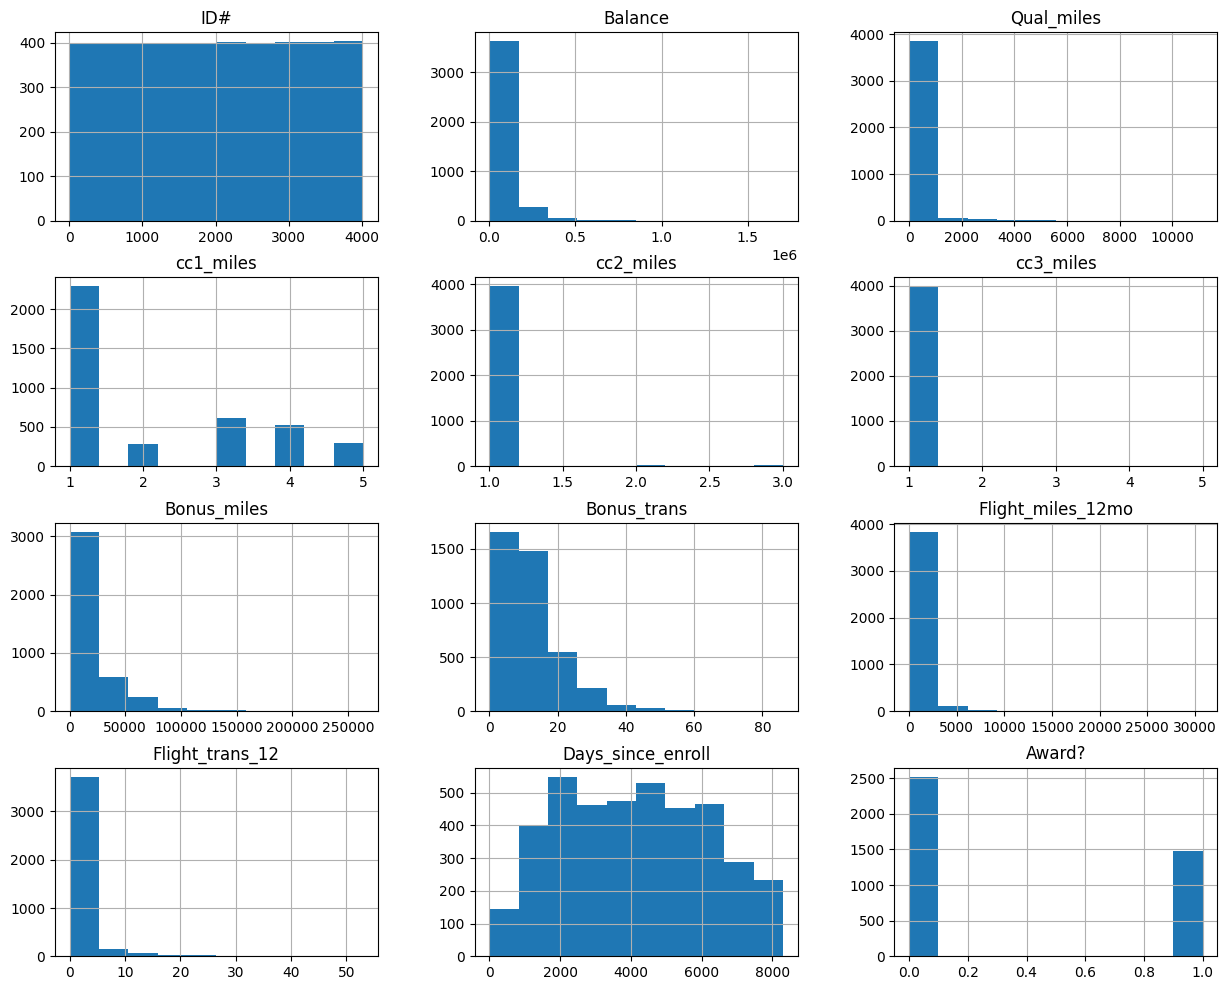

In [8]:
df.hist(figsize=(15,12))
plt.show()

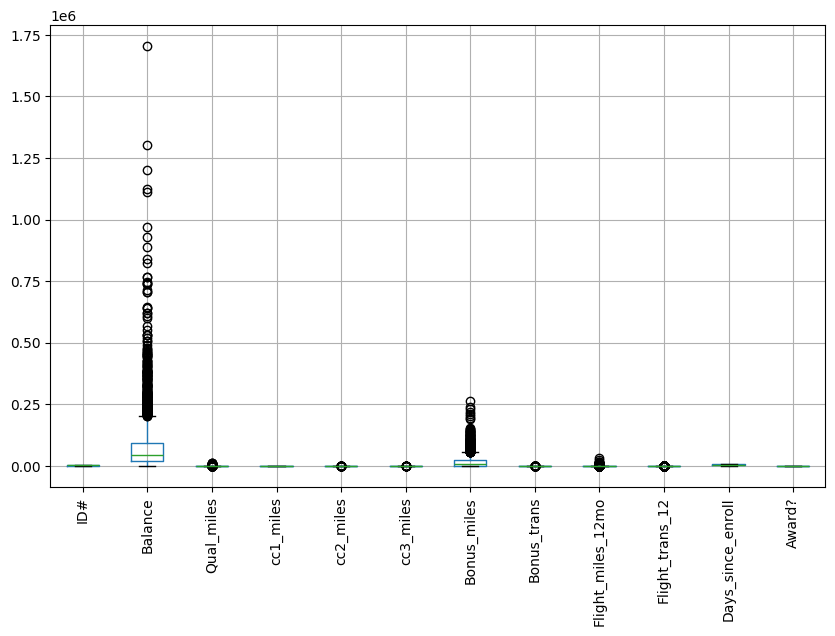

In [9]:
plt.figure(figsize=(10,6))
df.boxplot(rot=90)
plt.show()

you can see there are many outliers in balance and bonus miles. But they also have wide range in the data. They are strongly right skewed data.

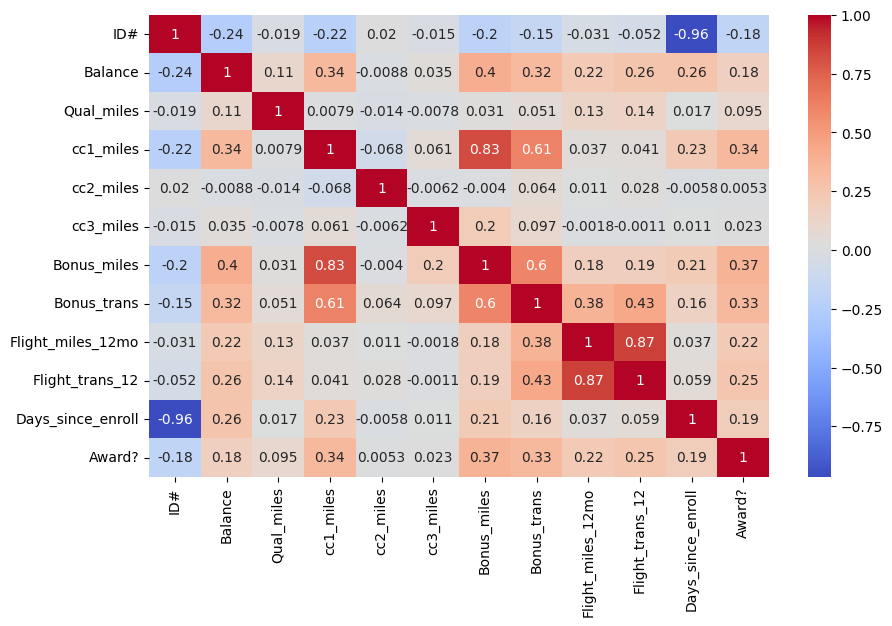

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap ='coolwarm',annot=True)
plt.show()

# Data Preprocessing

In [11]:
df_cleaned = df.drop(columns=['ID#'])

In [12]:
df_cleaned

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

In [14]:
df_scaled

array([[-4.51140783e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.39545434e+00, -7.66919299e-01],
       [-5.39456874e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.37995704e+00, -7.66919299e-01],
       [-3.20031232e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.41192021e+00, -7.66919299e-01],
       ...,
       [-4.29480975e-05, -1.86298687e-01,  6.83121167e-01, ...,
        -3.62167870e-01, -1.31560393e+00,  1.30391816e+00],
       [-1.85606976e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -9.85033311e-02, -1.31608822e+00, -7.66919299e-01],
       [-7.00507951e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01, -1.31754109e+00, -7.66919299e-01]])

scaled the data since balance and other high value features may dominate the model if kept unchecked

# K-Means Clustering

In [15]:
from sklearn.cluster import KMeans
Kmeans = KMeans(n_clusters= 3, random_state=42)
cluster_labels = Kmeans.fit_predict(df_scaled)

In [16]:
df_clustered = df_cleaned.copy()
df_clustered['cluster'] = cluster_labels

In [17]:
df_clustered

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2
1,19244,0,1,1,1,215,2,0,0,6968,0,2
2,41354,0,1,1,1,4123,4,0,0,7034,0,2
3,14776,0,1,1,1,500,1,0,0,6952,0,2
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,54899,0,1,1,1,500,1,500,1,1401,0,2


In [18]:
import matplotlib.pyplot as plt

inertia = []

K_range =range(2,11)

for i in K_range:
    km =KMeans(n_clusters=i, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

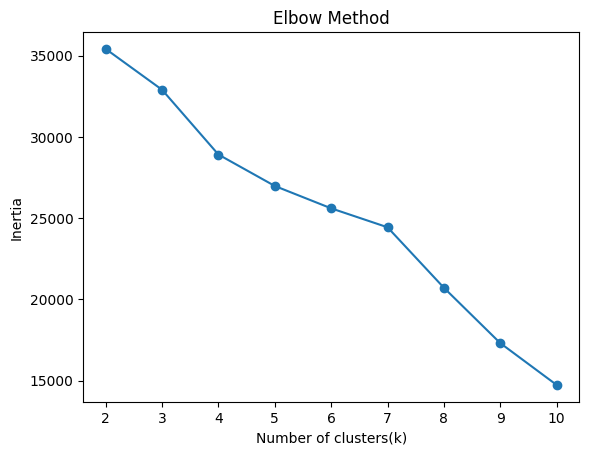

In [19]:
plt.plot(K_range,inertia,marker='o')
plt.xlabel("Number of clusters(k)")
plt.ylabel('Inertia')
plt.title("Elbow Method")
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled,labels)
    print(f"k={k},Silhouette_score={score:.3f}")

k=2,Silhouette_score=0.325
k=3,Silhouette_score=0.267
k=4,Silhouette_score=0.191
k=5,Silhouette_score=0.201
k=6,Silhouette_score=0.211
k=7,Silhouette_score=0.222


although k=2 gives the highest silhouette score , it resulted in  overly broad clusters. A slightly lower silhouette score at k=3 provided more interpreteable and meaningfull customer segments, therefore, k=3 was selected as an appropriate balance between clusters separations.

In [21]:
df_clustered['cluster'].value_counts()

cluster
2    2122
0     955
1     922
Name: count, dtype: int64

In [22]:
df_clustered.groupby('cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
cluster,,,,,,,,,,,
0,68022.381152,377.851309,1.633508,1.023037,1.000000,11078.913089,11.972775,978.223037,2.854450,4250.027225,0.943455
1,147282.027115,127.069414,4.146421,1.003254,1.052061,50995.211497,21.040130,675.880694,2.058568,5066.104121,0.629067
2,44098.164939,46.327992,1.344486,1.015551,1.000471,5166.961828,7.334119,133.081056,0.409519,3647.688501,0.000000


Cluster2:
Newer customers are the ones who fly rarely. those are the ones who have the lowest balance and never received  award. these could be labeled as inactive customers

cluster 0: 
flies much more than the inactive ones, also have medium balance ranges.  almost all of them have rewards. These are the loyal customers, these are not the high spendors but are frequent. can be labeled as loyal frequent flyers.

cluster 1: 
in this the balance is very high , bonus miles is also high. these are the oldest customers. but they do not fly frequently  as cluster 0. these could be premium members. high value premium customers.(Extremely valuable)

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

In [24]:
df['Cluster'].value_counts()

Cluster
2    2122
0     955
1     922
Name: count, dtype: int64

In [25]:
df.groupby('Cluster').mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,,
0,1963.008377,68022.381152,377.851309,1.633508,1.023037,1.000000,11078.913089,11.972775,978.223037,2.854450,4250.027225,0.943455
1,1498.352495,147282.027115,127.069414,4.146421,1.003254,1.052061,50995.211497,21.040130,675.880694,2.058568,5066.104121,0.629067
2,2262.539585,44098.164939,46.327992,1.344486,1.015551,1.000471,5166.961828,7.334119,133.081056,0.409519,3647.688501,0.000000


# heirarchial clustering

we need to check if there us any hierarchy in the customer behaviour

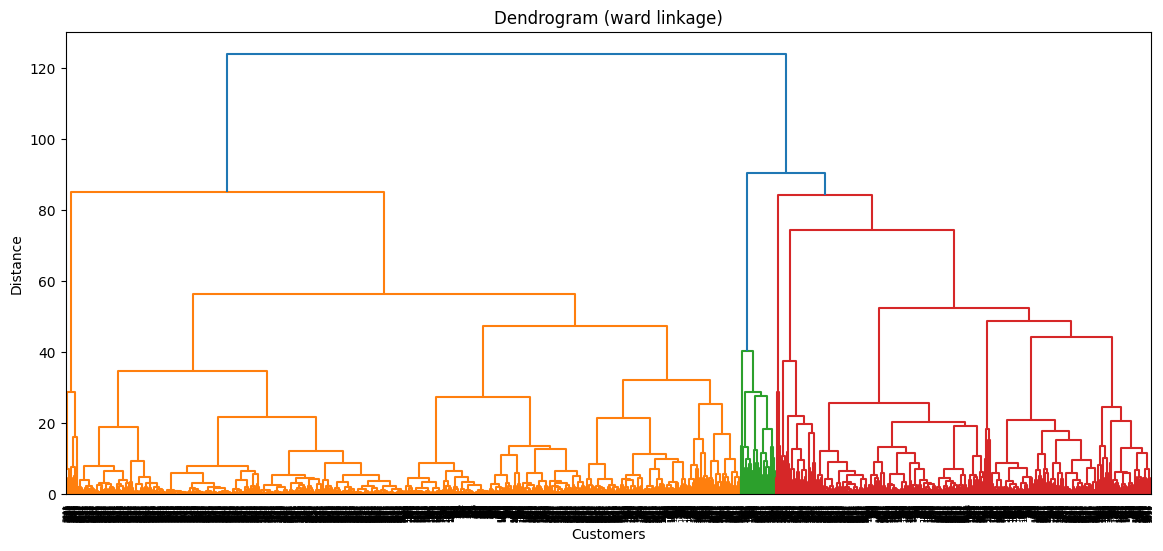

In [26]:
from scipy.cluster.hierarchy import linkage,dendrogram

linked = linkage(df_scaled,method='ward')
plt.figure(figsize=(14,6))
dendrogram(linked)
plt.title('Dendrogram (ward linkage)')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

the jump is in between 80 to 120 so we should take 3 clusters again.

In [27]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['HC_cluster'] = hc.fit_predict(df_scaled)

In [28]:
df.groupby('HC_cluster').mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
HC_cluster,,,,,,,,,,,,,
0,2198.450783,46718.863399,9.274407,1.242266,1.023303,1.000000,5037.792688,7.091201,221.167135,0.700281,3772.785858,0.188027,1.616312
1,1707.093478,116314.450725,363.839130,3.498551,1.000000,1.035507,37150.356522,18.066667,377.000000,1.150000,4696.888406,0.663043,0.789855
2,1765.615385,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846,0.407692


In [29]:
silhouette_score(df_scaled, df['HC_cluster'])

0.2940432062008608

the silhouette score is moderate in hierarchial clustering compared to others

you can above also that here also cluster 2 represents the most valuablecustomers, basically they are vip or high value customers, cluster 1 represent smart travelers who can be loyal frequent customers. and cluster 0 are the new and fly rarely.

# DBSCAN

In [30]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 1.5, min_samples = 5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)


In [31]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64

In [32]:
df.groupby('DBSCAN_Cluster').mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster,HC_cluster
DBSCAN_Cluster,,,,,,,,,,,,,,
-1,1643.106452,215733.335484,1381.900000,2.764516,1.070968,1.158065,45721.603226,25.261290,2994.580645,8.758065,4818.754839,0.729032,0.609677,1.270968
0,2180.509747,56525.714641,29.252178,1.684363,1.000000,1.000000,9589.272501,8.728743,173.045209,0.512650,3805.321858,0.000000,1.855662,0.180423
1,1774.310400,72115.619200,61.918400,2.632000,1.000000,1.000000,24773.415200,13.712800,392.944800,1.223200,4567.045600,1.000000,0.365600,0.648800
2,2453.933333,38556.733333,0.000000,1.000000,2.000000,1.000000,8951.533333,12.933333,60.000000,0.400000,3390.400000,0.000000,2.000000,0.000000
3,2671.625000,36524.250000,0.000000,1.000000,3.000000,1.000000,15518.500000,14.500000,50.000000,0.250000,3179.625000,0.000000,2.000000,0.000000
4,2924.200000,31161.600000,0.000000,1.000000,2.000000,1.000000,8723.400000,13.800000,350.000000,1.000000,3314.800000,1.000000,0.000000,0.000000


In [33]:
mask = df['DBSCAN_Cluster'] != -1
silhouette_score(df_scaled[mask],df['DBSCAN_Cluster'][mask])

0.29403795451062353

dbscan identifies dense regions and noise making silhourttr score less stable due to presence of outliers

DBSCAN identifies the dense group of customers while labeling less frequent behaviour pattern as noise , which may indicate the presence of outliers.

# evaluation

clustering performance was evaluated using internal validation metrics such as the silhouette score which provided us with above insights.

heirarchial clustering produces clusters with characteristics similar to kmeans although the cluster labels and sizes differed.  Dbscan also provided the same insights but with catching some noise in the process. 

Since the dataset is high dimentional , we will be using PCA for data reduction to two components for visualization purpose.
this allows better visualization of cluster separations, clustering evaluation was performed on the original scaled features.

we cannot visualize 11 dimentions directly  so we need PCA

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

df['PC1'] =pca_data[:,0]
df['PC2'] =pca_data[:,1]

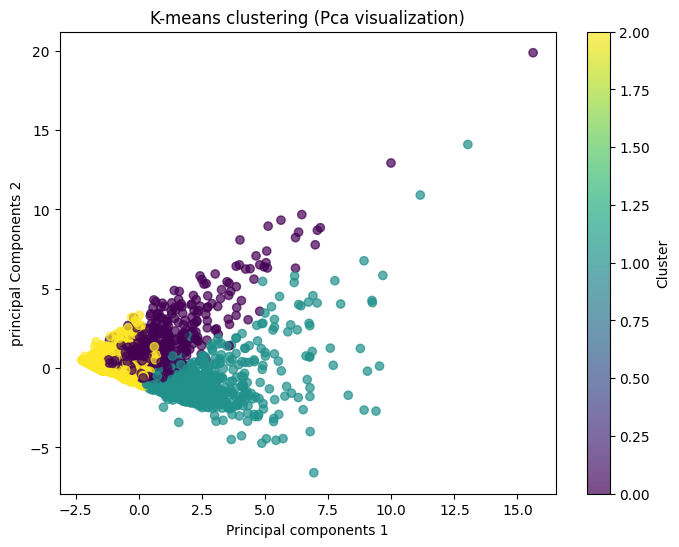

In [35]:
plt.figure(figsize =(8,6))
plt.scatter(df['PC1'],df['PC2'], c=df['Cluster'], cmap='viridis',alpha =0.7)
plt.xlabel('Principal components 1')
plt.ylabel('principal Components 2')
plt.title('K-means clustering (Pca visualization)')

plt.colorbar(label ='Cluster')
plt.show()

you can see in above graaph that there are 3 clusters, one compact cluster near the origin, one spread towards the right , one mid density in between . low activity customeers are ttightly clusterd around the origin. high value customers are spread towards right while the moderate customers are in middle.

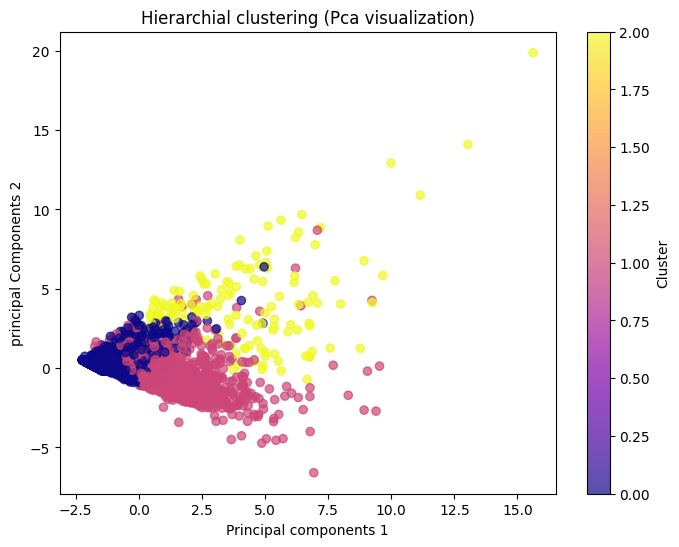

In [36]:
plt.figure(figsize =(8,6))
plt.scatter(df['PC1'],df['PC2'], c=df['HC_cluster'], cmap='plasma',alpha =0.7)
plt.xlabel('Principal components 1')
plt.ylabel('principal Components 2')
plt.title('Hierarchial clustering (Pca visualization)')

plt.colorbar(label ='Cluster')
plt.show()

in this also there are 3 clusters , one cluster dominating the dense region. another cluster capture extreme values

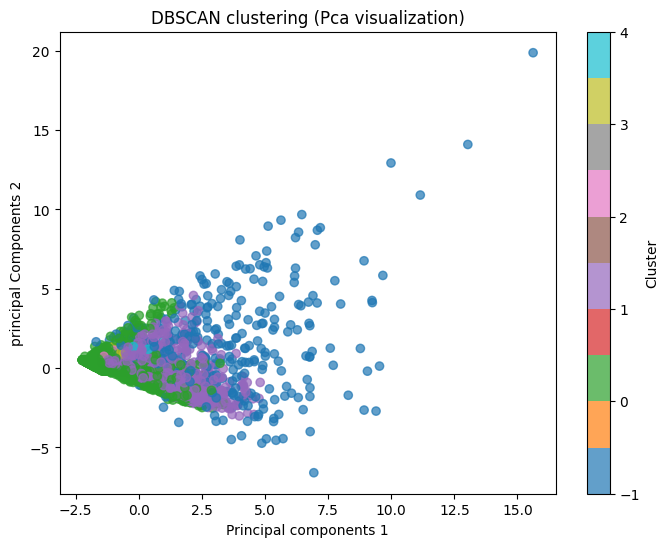

In [37]:
plt.figure(figsize =(8,6))
plt.scatter(df['PC1'],df['PC2'], c=df['DBSCAN_Cluster'], cmap='tab10',alpha =0.7)
plt.xlabel('Principal components 1')
plt.ylabel('principal Components 2')
plt.title('DBSCAN clustering (Pca visualization)')

plt.colorbar(label ='Cluster')
plt.show()

you can see that the data doesnt have clean density clusters. it means there are outliers in the data , which means not all customers fit in particular segments.

# conclusion

PCA visuals show that k-means and hierarchial clustering produce broadly similar customer segments, indicating stable underlying patterns in the data. DBSCAN identifies dense regions  and labels several points as noise, suggetsing presense of outliers.